# Machine Learning 2 - Assignment #2
# Data Science Specialization
# University of Antioquia

**Professor**: Hernán Felipe Garcáa Arias, PhD

## Overview

In this assignment, you will explore **dimensionality reduction techniques** and their impact on clustering tasks. You will apply **PCA**, **Kernel PCA**, **t-SNE**, and **UMAP** to project high-dimensional data into a lower-dimensional space and analyze whether these techniques improve the separability of clusters.

Furthermore, you will evaluate the effectiveness of these embeddings by performing **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** on the transformed datasets.

## Objectives

By the end of this assignment, students will be able to:
1. Implement and compare different dimensionality reduction techniques.
2. Analyze the quality of embeddings and their suitability for clustering.
3. Apply DBSCAN to assess the separability of clusters in reduced feature spaces.

## Datasets

Students can choose one of the following datasets:

* **FIFA 23 Players Dataset**: Contains detailed attributes of professional soccer players. The goal is to investigate whether dimensionality reduction can enhance player segmentation based on skill sets.
  - Features of interest: Age, Overall rating, Potential, Value, Wage, Shooting, Passing, Dribbling, Defending, and Physicality.
  
Dataset available on Kaggle [FIFA 23 Dataset - Kaggle](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database?select=FIFA23_official_data.csv)

* **EastWestAirlines Dataset**: Contains airline customer behavior data. The objective is to assess whether dimensionality reduction aids in segmenting customer profiles based on usage patterns. Dataset available here

## Tasks

1. **Dimensionality Reduction**: Implement the following techniques and visualize their embeddings:
   * **Principal Component Analysis (PCA)**
   * **Kernel PCA**
   * **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
   * **UMAP (Uniform Manifold Approximation and Projection)**
  
   For each technique, analyze:
   * How well the data is preserved in lower dimensions.
   * Whether clusters appear more defined.
  
2. **Clustering with DBSCAN**: Apply **DBSCAN** to the reduced-dimensional data and evaluate:
   * How clustering performance is affected by different embeddings.
   * The number of clusters detected in each case.
   * The presence of noise (points classified as outliers).

3. **Comparison and Analysis**:
   * Compare the four dimensionality reduction methods in terms of cluster separability.
   * Identify which method best preserves structure for clustering.
   * Discuss whether the reduced feature space provides a meaningful representation for classification or decision-making.

## Deliverables

* Teams must submit an **IPYNB notebook (Jupyter notebook)** containing:
  - Implementations of **PCA**, **Kernel PCA**, **t-SNE**, and **UMAP**.
  - Visual comparisons of embeddings (e.g., scatter plots).
  - Application of **DBSCAN** to analyze clustering behavior in the embedded space.
  - Interpretation and discussion of findings.

* The notebook should be well-documented with **Markdown cells** explaining each step and analysis.

## Hints and Useful Links

* **PCA and Kernel PCA**: [Scikit-learn: PCA and Kernel PCA](https://scikit-learn.org/stable/modules/decomposition.html).
* **t-SNE**: Scikit-learn: [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).
* **UMAP**: [UMAP Documentation](https://umap-learn.readthedocs.io/en/latest/).
* **DBSCAN**: [Scikit-learn: DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html).

## Grading Rubric

* **Correctness of Implementation (40%)**: Accurate implementation of dimensionality reduction techniques and clustering.
* **Evaluation and Analysis (30%)**: Comparison of embeddings and their effects on clustering.
* **Visualization and Reporting (20%)**: Well-structured figures and discussion.
* **Code Quality (10%)**: Readability, documentation, and organization.

## Submission

Please submit your Jupyter notebooks in IPYNB format, including all code, analysis, and documentation. The deadline for this assignment is **19/03/2025**.

## Librerias y configuraciones previas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.metrics import rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Funciones

A continuación se colocan las funciones suministradas por el profesor.

In [ ]:
# Function to generate a positive definite covariance matrix
def generate_positive_definite_matrix(d):
    A = np.random.randn(d, d)
    return np.dot(A, A.T) + np.eye(d) * epsilon  # Add identity for stability

# Ensure covariance matrix is positive definite
def ensure_positive_definite(Sigma):
    return Sigma + np.eye(Sigma.shape[0]) * epsilon

# Expectation Step (E-step)
def expectation_step(X, mu, Sigma, pi):
    """ Compute responsibilities (γ) given current parameters. """
    gamma = np.zeros((n, K))
    for k in range(K):
        try:
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=ensure_positive_definite(Sigma[k]))
        except np.linalg.LinAlgError:
            print(f"Warning: Fixing singular covariance matrix for cluster {k}")
            Sigma[k] = ensure_positive_definite(Sigma[k])
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k])

    gamma += epsilon  # Prevents division by zero
    gamma /= gamma.sum(axis=1, keepdims=True)  # Normalize
    return gamma

# Maximization Step (M-step)
def maximization_step(X, gamma):
    """ Update parameters based on responsibilities. """
    Nk = gamma.sum(axis=0)  # Effective cluster size
    pi_new = Nk / n  # Update mixing coefficients
    mu_new = np.dot(gamma.T, X) / Nk[:, np.newaxis]  # Update means

    Sigma_new = np.zeros((K, d, d))
    for k in range(K):
        X_centered = X - mu_new[k]
        Sigma_new[k] = np.dot(gamma[:, k] * X_centered.T, X_centered) / Nk[k]
        Sigma_new[k] = ensure_positive_definite(Sigma_new[k])  # Ensure positive definiteness

    return pi_new, mu_new, Sigma_new

# Compute Log-Likelihood
def compute_log_likelihood(X, pi, mu, Sigma):
    """ Compute the Log-Likelihood to monitor convergence. """
    log_likelihood = 0
    for k in range(K):
        try:
            prob = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=ensure_positive_definite(Sigma[k]))
            prob += epsilon  # Prevents log(0)
            log_likelihood += np.sum(np.log(prob))
        except np.linalg.LinAlgError:
            print(f"Warning: Fixing covariance matrix for cluster {k}")
            Sigma[k] = ensure_positive_definite(Sigma[k])
            prob = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k]) + epsilon
            log_likelihood += np.sum(np.log(prob))

    return log_likelihood

# Codigo del profe reescrito con la ayuda de Skynet
def expectation_maximization(X_norm, mu, Sigma, pi, max_iters=200, tol=1e-4):
    """
    Implementa el algoritmo de Expectation-Maximization (EM) con manejo de problemas numéricos.

    Parámetros:
    - X_norm: Datos de entrada normalizados.
    - mu: Medias iniciales de las distribuciones.
    - Sigma: Matrices de covarianza iniciales.
    - pi: Pesos iniciales de las componentes.
    - max_iters: Número máximo de iteraciones (default: 200).
    - tol: Umbral de convergencia para la diferencia del log-verosimilitud (default: 1e-4).

    Retorna:
    - pi: Pesos finales de las componentes.
    - mu: Medias finales de las distribuciones.
    - Sigma: Matrices de covarianza finales.
    - gamma: Matriz de responsabilidades finales.
    - log_likelihoods: Lista con la evolución del log-verosimilitud.
    """
    log_likelihoods = []
    prev_log_likelihood = -np.inf  # Inicializar con un valor muy bajo
    gamma = None  # Inicializar gamma fuera del bucle

    for i in range(max_iters):
        gamma = expectation_step(X_norm, mu, Sigma, pi)

        # Verificación de NaN o valores no válidos en gamma
        if np.isnan(gamma).any() or np.isinf(gamma).any():
            print("Se detectaron valores NaN en la matriz de responsabilidades. Deteniendo EM.")
            break

        pi, mu, Sigma = maximization_step(X_norm, gamma)

        # Evitar matrices de covarianza singulares
        for j in range(len(Sigma)):
            if np.linalg.det(Sigma[j]) == 0:
                print(f"Advertencia: Covarianza singular en la componente {j}. Ajustando...")
                Sigma[j] += np.eye(Sigma[j].shape[0]) * 1e-6  # Agregar regularización

        # Calcular log-verosimilitud
        log_likelihood = compute_log_likelihood(X_norm, pi, mu, Sigma)

        # Verificación de NaN o valores no válidos en log-likelihood
        if np.isnan(log_likelihood) or np.isinf(log_likelihood):
            print("Se detectaron valores NaN o Inf en el log-verosimilitud. Deteniendo EM.")
            break

        log_likelihoods.append(log_likelihood)
        print(f"Iteración {i+1}, Log-Verosimilitud: {log_likelihood:.4f}")

        # Verificar convergencia
        if np.abs(log_likelihood - prev_log_likelihood) < tol:
            print(f"Convergencia alcanzada en la iteración {i+1}.")
            break

        prev_log_likelihood = log_likelihood

    # Graficar evolución del log-verosimilitud
    if len(log_likelihoods) > 1:
        plt.plot(log_likelihoods)
        plt.xlabel('Iteraciones')
        plt.ylabel('Log-Verosimilitud')
        plt.title('Convergencia del Log-Verosimilitud en el Algoritmo EM')
        plt.show()

    return pi, mu, Sigma, gamma, log_likelihoods

## Dataset Fifa 23

### 1. Carga de datos

Se a carga el dataset como un dataframe mostrando las primeras filas para inspección:

In [ ]:
# Se carga el dataset
csv_file = 'FIFA23_official_data.csv'
df_players = pd.read_csv(csv_file)
df_players.head(3)

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,...,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,...,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,...,No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN


### 2. EDA

Se obtiene el numero de filas y columnas del dataframe

In [ ]:
(f,c) = df_players.shape
print(f"El numero de filas en el dataset es de {f}") # Filas
print(f"El numero de columnas en el dataset es de {c}") # Columnas

El numero de filas en el dataset es de 17660
El numero de columnas en el dataset es de 29


Se inspecciona la informacion general del dataset

In [ ]:
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        17660 non-null  int64  
 1   Name                      17660 non-null  object 
 2   Age                       17660 non-null  int64  
 3   Photo                     17660 non-null  object 
 4   Nationality               17660 non-null  object 
 5   Flag                      17660 non-null  object 
 6   Overall                   17660 non-null  int64  
 7   Potential                 17660 non-null  int64  
 8   Club                      17449 non-null  object 
 9   Club Logo                 17660 non-null  object 
 10  Value                     17660 non-null  object 
 11  Wage                      17660 non-null  object 
 12  Special                   17660 non-null  int64  
 13  Preferred Foot            17660 non-null  object 
 14  Intern

Antes de proseguir, se renombran las columnas del dataset a un formato mas apropiado.

In [ ]:
df_players.columns = df_players.columns.str.replace(' ', '_')
df_players.columns = df_players.columns.str.lower()
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        17660 non-null  int64  
 1   name                      17660 non-null  object 
 2   age                       17660 non-null  int64  
 3   photo                     17660 non-null  object 
 4   nationality               17660 non-null  object 
 5   flag                      17660 non-null  object 
 6   overall                   17660 non-null  int64  
 7   potential                 17660 non-null  int64  
 8   club                      17449 non-null  object 
 9   club_logo                 17660 non-null  object 
 10  value                     17660 non-null  object 
 11  wage                      17660 non-null  object 
 12  special                   17660 non-null  int64  
 13  preferred_foot            17660 non-null  object 
 14  intern

Se revisa la existencia de valores nulos

In [ ]:
print(df_players.isnull().sum())

id                              0
name                            0
age                             0
photo                           0
nationality                     0
flag                            0
overall                         0
potential                       0
club                          211
club_logo                       0
value                           0
wage                            0
special                         0
preferred_foot                  0
international_reputation        0
weak_foot                       0
skill_moves                     0
work_rate                       0
body_type                      38
real_face                      38
position                       35
joined                       1098
loaned_from                 16966
contract_valid_until          361
height                          0
weight                          0
release_clause               1151
kit_number                     35
best_overall_rating         17639
dtype: int64


**Conclusiones**:
* Los datos se ven bien conformados pero hay algunos valores que se identifican como categoricos y deben volverse númericos para el análisis, entre ellos "value" y "wave" que se intuyen como variables relevantes.

#### Estadistica descriptiva

Se procede a obtener las estadisticas de las variables categoricas y numericas.

##### Variables categoricas

In [ ]:
# Columnas categoricas
player_catCols = df_players.select_dtypes(include = ["object", 'category']).columns.tolist()
df_players[player_catCols].head(2)

,name,photo,nationality,flag,club,club_logo,value,wage,preferred_foot,work_rate,body_type,real_face,position,joined,loaned_from,contract_valid_until,height,weight,release_clause,best_overall_rating
0,L. Goretzka,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,€91M,€115K,Right,High/ Medium,Unique,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,NaN
1,Bruno Fernandes,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,Manchester United,https://cdn.sofifa.net/teams/11/30.png,€78.5M,€190K,Right,High/ High,Unique,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,NaN


In [ ]:
len(player_catCols)

20

Si observamos hay varias columnas que no son de utilidad, por ejemplo **`photo`** y **`body_type`**. Sin embargo, vemos que otras como **`value`** y **`wage`** tienen que ver con dinero por lo que consideramos que son datos relevantes que pueden ser tomados como numericos, pero esta transformación se hara luego.

Ahora veamos la cantidad de valores unicos por categoria:

In [ ]:
cantidad_valores_cat_unicos = df_players[player_catCols].nunique()
cantidad_valores_cat_unicos

,0
name,17140
photo,17660
nationality,161
flag,161
club,926
club_logo,970
value,258
wage,135
preferred_foot,2
work_rate,10


Vamos a realizar una inspección un poco mas detallada de aquellas columnas categoricas con menos de 60 valores distintos.

In [ ]:
# Filtrado de las columnas
player_catCols_filter = df_players[player_catCols].nunique() <= 30
categorical_cols_to_keep = player_catCols_filter[player_catCols_filter].index
print(categorical_cols_to_keep)
# Despliegue de las columnas filtradas
df_players[categorical_cols_to_keep].head(4)

Index(['preferred_foot', 'work_rate', 'body_type', 'real_face', 'position',
       'best_overall_rating'],
      dtype='object')


,preferred_foot,work_rate,body_type,real_face,position,best_overall_rating
0,Right,High/ Medium,Unique,Yes,"<span class=""pos pos28"">SUB",NaN
1,Right,High/ High,Unique,Yes,"<span class=""pos pos15"">LCM",NaN
2,Left,High/ High,Stocky (170-185),No,"<span class=""pos pos7"">LB",NaN
3,Right,High/ High,Unique,Yes,"<span class=""pos pos13"">RCM",NaN


Reescribiendo el contenido de la columna position de una forma mas clara e inspeccionando el resultado se tiene:

In [ ]:
df_players['position'] = df_players['position'].astype(str).str.split('>').str[-1]
df_players[categorical_cols_to_keep].head(4)

,preferred_foot,work_rate,body_type,real_face,position,best_overall_rating
0,Right,High/ Medium,Unique,Yes,SUB,NaN
1,Right,High/ High,Unique,Yes,LCM,NaN
2,Left,High/ High,Stocky (170-185),No,LB,NaN
3,Right,High/ High,Unique,Yes,RCM,NaN


Ahora vamos a observar graficamente algunas de las categorias anteriormente mostradas con el fin de tener mas ilustración al respecto:

**Preferred Foot**

<ipython-input-13-500427a2e948>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'preferred_foot', data = df_players, palette = 'colorblind')


([0, 1], [Text(0, 0, 'Right'), Text(1, 0, 'Left')])

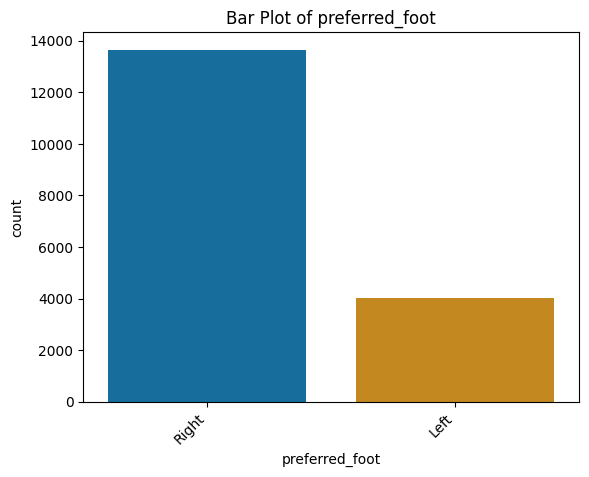

In [ ]:
sns.countplot(x = 'preferred_foot', data = df_players, palette = 'colorblind')
plt.title(f'Bar Plot of preferred_foot')
plt.xticks(rotation=45, ha='right')

De la grafica anterior podemos ver que hay un número mucho mayor de jugadores derechos

**Work Rate**

<ipython-input-14-f67e19bdee58>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'work_rate', data = df_players, palette = 'colorblind')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'High/ Medium'),
  Text(1, 0, 'High/ High'),
  Text(2, 0, 'Medium/ Medium'),
  Text(3, 0, 'Medium/ High'),
  Text(4, 0, 'High/ Low'),
  Text(5, 0, 'Low/ Low'),
  Text(6, 0, 'Low/ High'),
  Text(7, 0, 'Medium/ Low'),
  Text(8, 0, 'Low/ Medium'),
  Text(9, 0, 'N/A/ N/A')])

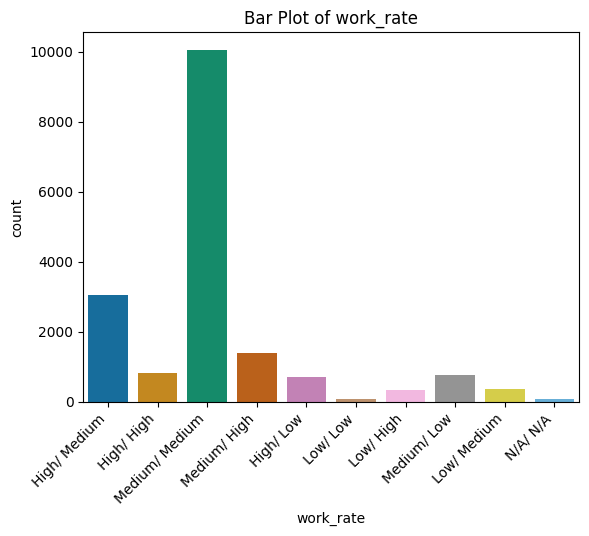

In [ ]:
sns.countplot(x = 'work_rate', data = df_players, palette = 'colorblind')
plt.title(f'Bar Plot of work_rate')
plt.xticks(rotation=45, ha='right')

De la grafica anterior podemos ver que el work rate, que hace referencia a la participación de los jugadores en espectos ofensivos y defensivos, es mucho mayor, o está desbalanceado, para Medium/Medium.

**Body type**

<ipython-input-15-70b9a5a4440a>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'body_type', data = df_players, palette = 'colorblind')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Unique'),
  Text(1, 0, 'Stocky (170-185)'),
  Text(2, 0, 'Normal (170-)'),
  Text(3, 0, 'Normal (170-185)'),
  Text(4, 0, 'Stocky (185+)'),
  Text(5, 0, 'Lean (185+)'),
  Text(6, 0, 'Lean (170-185)'),
  Text(7, 0, 'Normal (185+)'),
  Text(8, 0, 'Lean (170-)'),
  Text(9, 0, 'Stocky (170-)')])

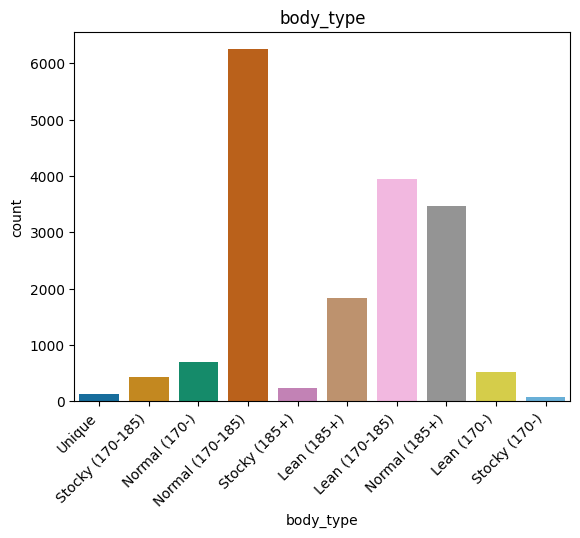

In [ ]:

sns.countplot(x = 'body_type', data = df_players, palette = 'colorblind')
plt.title(f'body_type')
plt.xticks(rotation=45, ha='right')

Si observamos la grafica anterior podemos ver que de igual forma hay desbalance de datos para el "tipo de cuerpo" Normal.

**Position**

<ipython-input-16-938dac324143>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'position', data = df_players, palette = 'colorblind')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'SUB'),
  Text(1, 0, 'LCM'),
  Text(2, 0, 'LB'),
  Text(3, 0, 'RCM'),
  Text(4, 0, 'RDM'),
  Text(5, 0, 'LCB'),
  Text(6, 0, 'RS'),
  Text(7, 0, 'RB'),
  Text(8, 0, 'LM'),
  Text(9, 0, 'LS'),
  Text(10, 0, 'RWB'),
  Text(11, 0, 'CDM'),
  Text(12, 0, 'RW'),
  Text(13, 0, 'RM'),
  Text(14, 0, 'LF'),
  Text(15, 0, 'LWB'),
  Text(16, 0, 'ST'),
  Text(17, 0, 'CAM'),
  Text(18, 0, 'LDM'),
  Text(19, 0, 'RES'),
  Text(20, 0, 'LW'),
  Text(21, 0, 'CF'),
  Text(22, 0, 'RF'),
  Text(23, 0, 'RCB'),
  Text(24, 0, 'CM'),
  Text(25, 0, 'CB'),
  Text(26, 0, 'nan'),
  Text(27, 0, 'RAM'),
  Text(28, 0, 'LAM'),
  Text(29, 0, 'GK')])

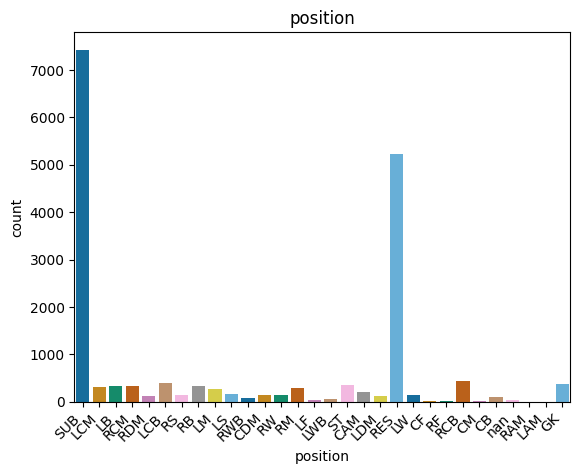

In [ ]:
sns.countplot(x = 'position', data = df_players, palette = 'colorblind')
plt.title(f'position')
plt.xticks(rotation=45, ha='right')

En general las variables categóricas muestran algún tipo de desvalence y vemos que estas puede ser usadas como agrupaciones para validar los cluster más adelante. En nuestro caso usaremos "Reputación Internacional".

##### Variables numericas

In [ ]:
# Columnas numericas
player_numCols = df_players.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
df_players[player_numCols].head(2)

,id,age,overall,potential,special,international_reputation,weak_foot,skill_moves,kit_number
0,209658,27,87,88,2312,4.0,4.0,3.0,8.0
1,212198,27,86,87,2305,3.0,3.0,4.0,8.0


De las variables númericas vistas que no aportan a nuestro conceptos son: **`id`** asi que de entrada la quitamos.

In [ ]:
try:
  player_numCols.remove('id')
except:
  pass

Veamos un poco mas de información estadistica de los datos numericos restantes:

In [ ]:
df_players[player_numCols].describe()

,age,overall,potential,special,international_reputation,weak_foot,skill_moves,kit_number
count,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17625.000000
mean,23.127746,63.369592,70.981200,1537.915855,1.106285,2.900340,2.297169,25.037957
std,4.639821,8.036268,6.529836,285.893809,0.407021,0.663523,0.754264,19.154116
min,15.000000,43.000000,42.000000,749.000000,1.000000,1.000000,1.000000,1.000000
25%,20.000000,58.000000,67.000000,1387.000000,1.000000,3.000000,2.000000,11.000000
50%,22.000000,63.000000,71.000000,1548.000000,1.000000,3.000000,2.000000,22.000000
75%,26.000000,69.000000,75.000000,1727.000000,1.000000,3.000000,3.000000,32.000000
max,54.000000,91.000000,95.000000,2312.000000,5.000000,5.000000,5.000000,99.000000


Miremos ahora la cantidad de datos diferentes en cada columna numerica:

In [ ]:
cantidad_valores_num_unicos = df_players[player_numCols].nunique()
print(cantidad_valores_num_unicos)

age                           31
overall                       49
potential                     50
special                     1428
international_reputation       5
weak_foot                      5
skill_moves                    5
kit_number                    99
dtype: int64


In [ ]:
for col in player_numCols:
    print(f"Column: {col}")
    print(df_players[col].value_counts())
    print("\n")

Column: age
age
20    1970
19    1937
21    1871
22    1686
18    1442
23    1240
24    1091
25     936
26     801
27     692
17     677
28     608
29     528
30     475
31     385
32     314
33     245
34     207
16     154
35     146
36     104
37      68
38      28
39      28
40      13
41       7
42       3
54       1
44       1
43       1
15       1
Name: count, dtype: int64


Column: overall
overall
60    978
62    932
63    918
64    903
61    897
65    806
59    774
58    734
66    671
57    647
67    646
56    600
68    576
55    568
53    530
69    520
54    514
70    502
72    463
52    444
75    422
71    416
73    387
51    350
74    333
50    332
76    308
77    211
78    193
79    190
49    155
80    136
48    116
81    114
82     84
84     63
47     60
83     51
85     27
86     22
46     16
87     14
88     11
89     10
90      5
91      5
44      3
45      2
43      1
Name: count, dtype: int64


Column: potential
potential
70    1212
68    1084
72    1080
69    1066
7

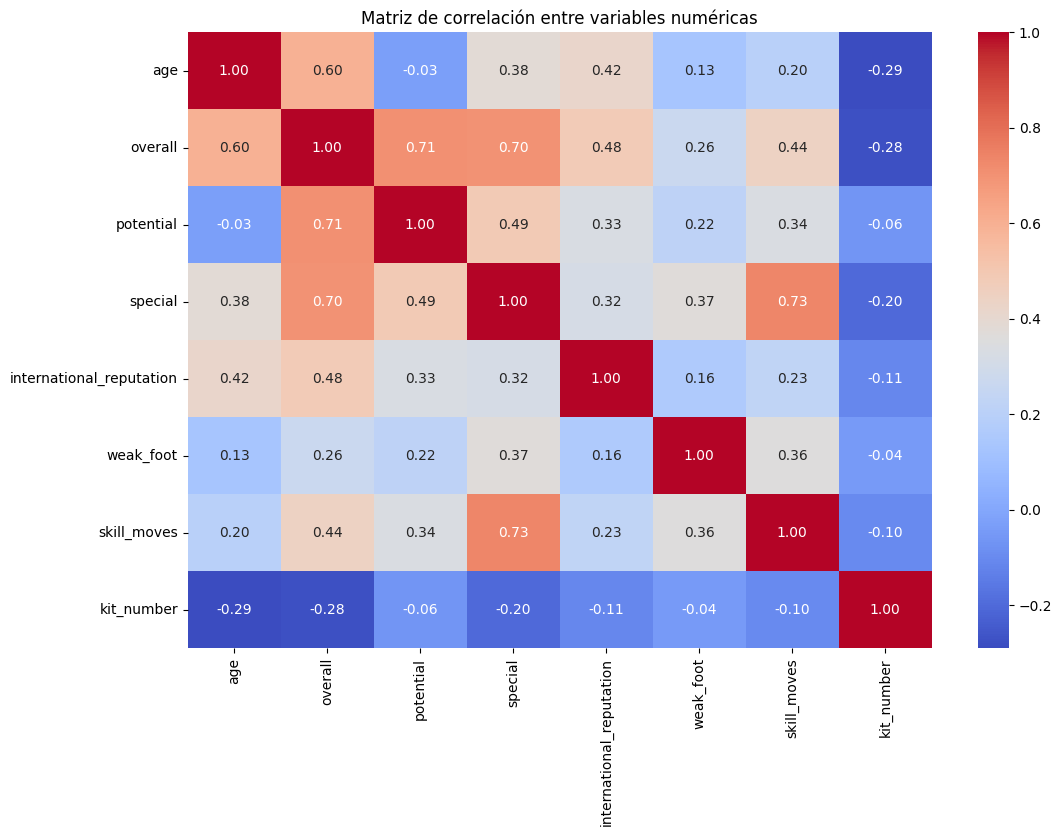

In [ ]:
# Matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df_players[player_numCols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Segun los resultados anteriores, las caracteristicas pese a ser numericas **`international_reputation`**, **`weak_foot`**, **`skill_moves`** se presumen categoricas. Para tener una mayor perspectiva se visualizaran de manera rapida los datos mediante un pairplot

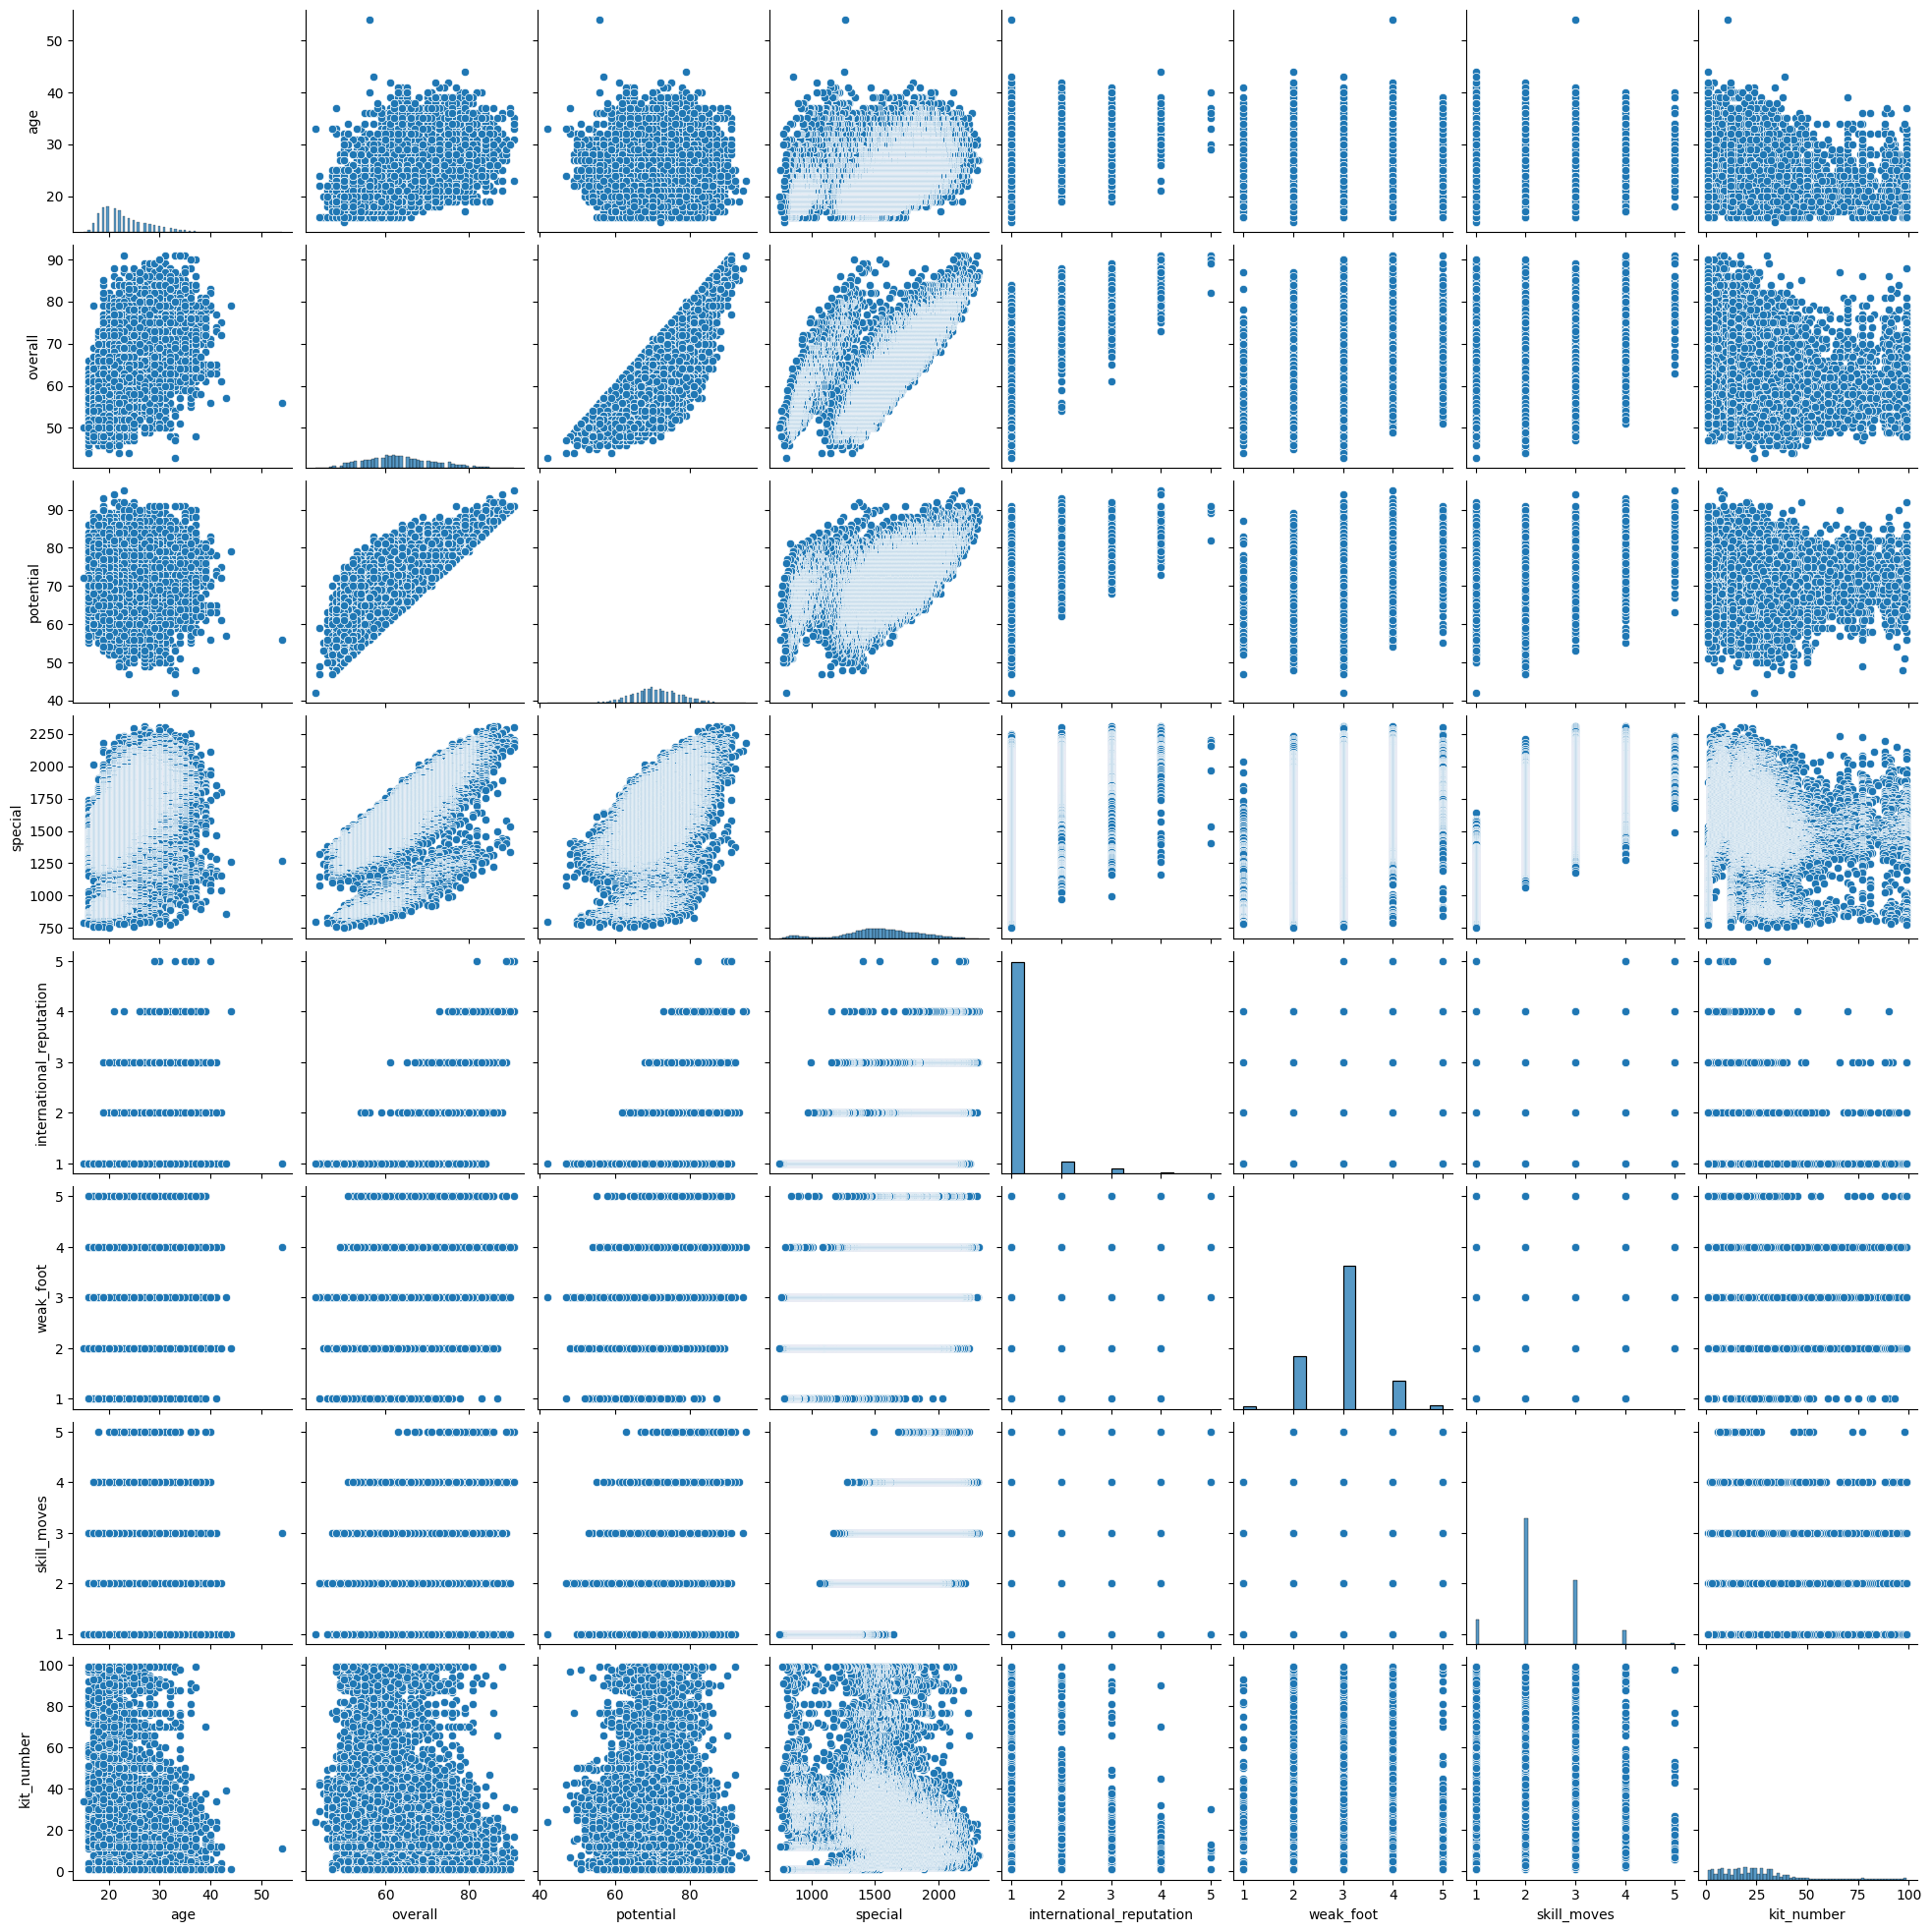

In [ ]:
sns.pairplot(df_players[player_numCols])
plt.show()

Al observar la grafica anterior, vamos a dejar para las columnas numericas de interes aquellas que no tienen una distribución tipo campana, para el caso: **`weak_foot`**, **`skill_moves`** y **`kit_number`**.

In [ ]:
player_numCols.remove('weak_foot')
player_numCols.remove('skill_moves')
player_numCols.remove('kit_number')
player_numCols

['age', 'overall', 'potential', 'special', 'international_reputation']

Vamos a definir un dataframe **`df`** de trabajo tomando inicialmente las columnas anteriores:

In [ ]:
features_selected = player_numCols + ['value', 'wage', 'height', 'weight']
#features_selected
df = df_players[features_selected]
df.head(2)

,age,overall,potential,special,international_reputation,value,wage,height,weight
0,27,87,88,2312,4.0,€91M,€115K,189cm,82kg
1,27,86,87,2305,3.0,€78.5M,€190K,179cm,69kg


Ademas, al inspeccionar la matriz de correlación decidimos quitar `overall` debido a su alta correlacion con `age`, `potential` y `special`

In [ ]:
features_selected.remove('overall')
df = df_players[features_selected]
df.head(2)

,age,potential,special,international_reputation,value,wage,height,weight
0,27,88,2312,4.0,€91M,€115K,189cm,82kg
1,27,87,2305,3.0,€78.5M,€190K,179cm,69kg


Como las dos ultimas son categoricas las vamos a volver numericas. A continuación se crean las funciones (creadas con la ayuda de Skynet) para tal fin:

In [ ]:
def convert_mk_to_numeric(value):
    if isinstance(value, str):  # Asegurar que el valor es una cadena
        if 'M' in value:
            return float(value.replace('M', '')) * 1e6
        elif 'K' in value:
            return float(value.replace('K', '')) * 1e3
        else:
            return float(value)
    return value  # Si no es string, devolver el valor original

def convert_height_to_numeric(height):
    if isinstance(height, str):  # Asegurar que el valor es una cadena
        return float(height.replace('cm', ''))
    return height  # Si no es string, devolver el valor original

def convert_weight_to_numeric(weight):
    if isinstance(weight, str):  # Asegurar que el valor es una cadena
        return float(weight.replace('kg', ''))
    return weight  # Si no es string, devolver el valor original

Aplicando las funciones anteriores para convertir las columnas a numericas tenemos:

In [ ]:
# Columna Value
df['value'] = df['value'].str[1:]
df['value']= df['value'].apply(convert_mk_to_numeric)

# Columna Wage
df['wage'] = df['wage'].str[1:]
df['wage'] = df['wage'].apply(convert_mk_to_numeric)

# Columna Height
df['height'] = df['height'].apply(convert_height_to_numeric)

# Columna Weight
df['weight'] = df['weight'].apply(convert_weight_to_numeric)

# Inspeccion del frame
df.head(2)

<ipython-input-28-500ef998ed91>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value'] = df['value'].str[1:]
<ipython-input-28-500ef998ed91>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value']= df['value'].apply(convert_mk_to_numeric)
<ipython-input-28-500ef998ed91>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

,age,potential,special,international_reputation,value,wage,height,weight
0,27,88,2312,4.0,91000000.0,115000.0,189.0,82.0
1,27,87,2305,3.0,78500000.0,190000.0,179.0,69.0


Para propositos de comparación con el cluster generado, vamos a emplear la variable `international_reputation` como variable de salida.

Ahora, analizamos el dataframe definitivo:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       17660 non-null  int64  
 1   potential                 17660 non-null  int64  
 2   special                   17660 non-null  int64  
 3   international_reputation  17660 non-null  float64
 4   value                     17660 non-null  float64
 5   wage                      17660 non-null  float64
 6   height                    17660 non-null  float64
 7   weight                    17660 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 1.1 MB


In [ ]:
cantidad_valores_unicos = df.nunique()
print(cantidad_valores_unicos)

age                           31
potential                     50
special                     1428
international_reputation       5
value                        258
wage                         135
height                        51
weight                        58
dtype: int64


In [ ]:
features_selected

['age',
 'potential',
 'special',
 'international_reputation',
 'value',
 'wage',
 'height',
 'weight']

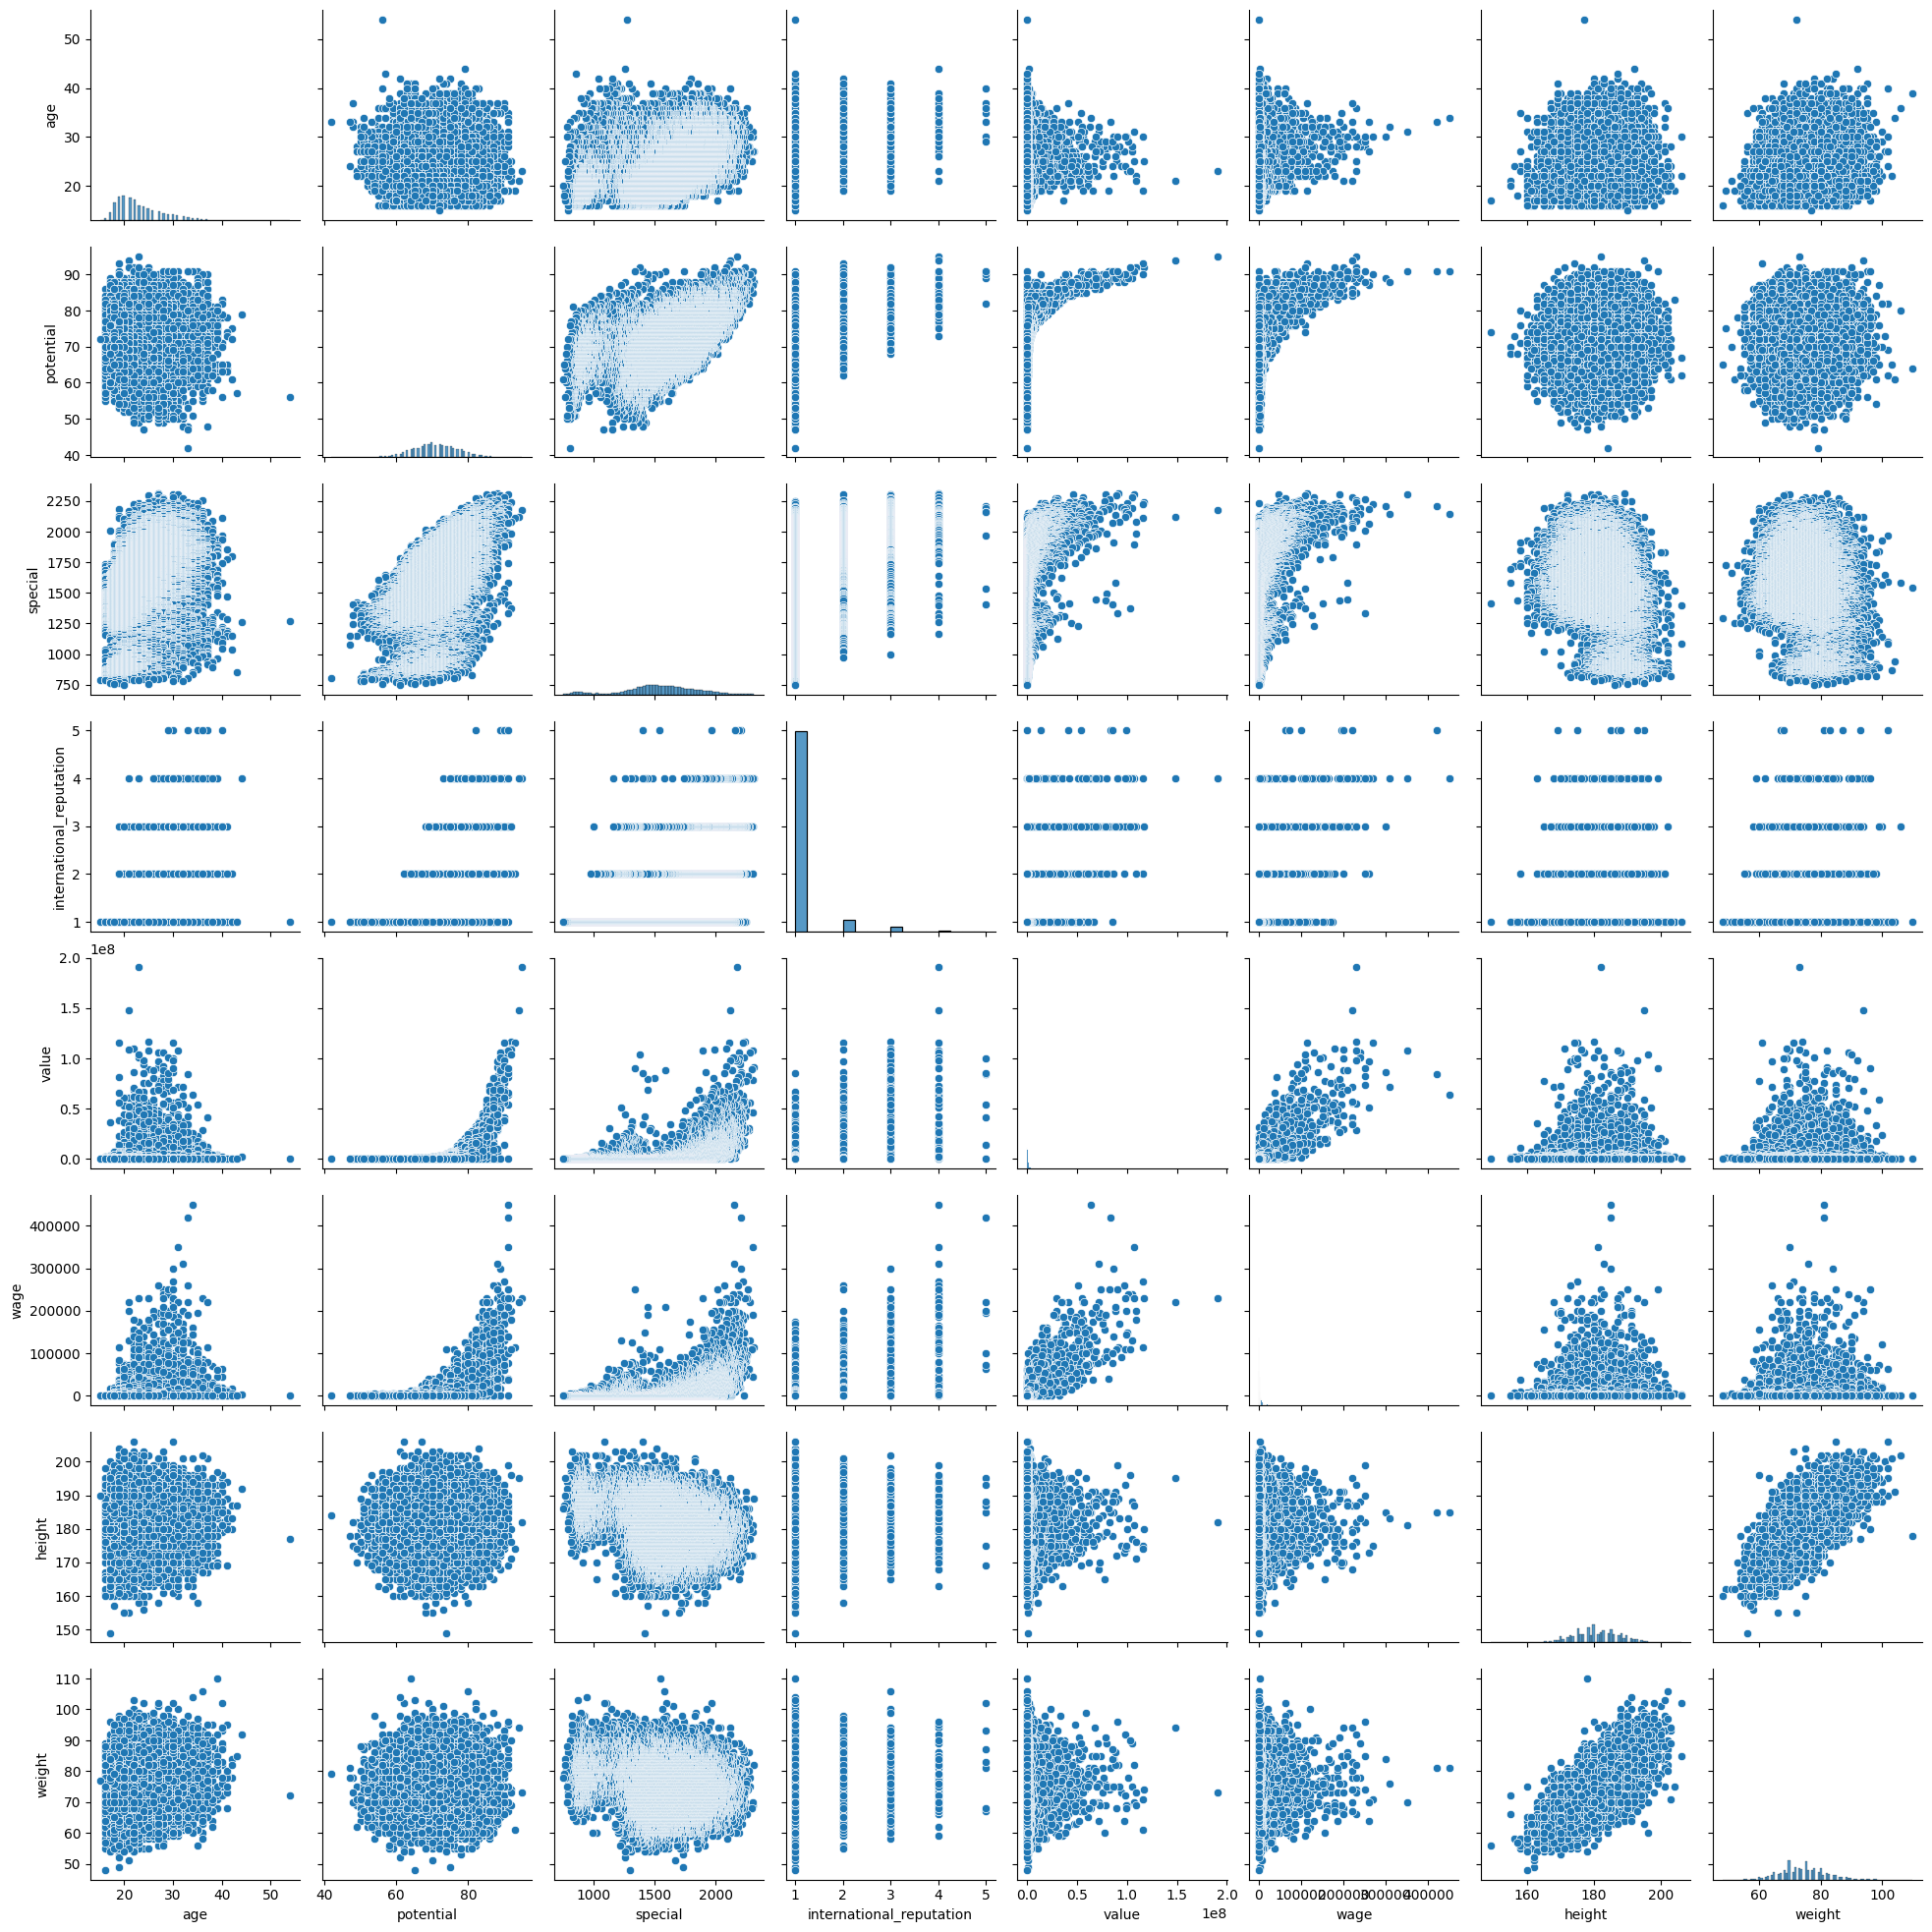

In [ ]:
sns.pairplot(df[features_selected])
plt.show()

### 3. Modelo GMM

In [ ]:
df['international_reputation'].unique()

array([4., 3., 2., 1., 5.])

Antes de empezar, como los valores de `international_reputation` van de 1 a 5, vamos a restarles 1 para que coincidan con el valor de los cluster cuando estos se generen y emplearemos estos como `labels` para la comparación.

In [ ]:
df['label'] = df['international_reputation'] - 1
df.sample(5)

<ipython-input-34-586861c5a7ad>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['international_reputation'] - 1


,age,potential,special,international_reputation,value,wage,height,weight,label
8302,18,75,1566,1.0,575000.0,1000.0,171.0,65.0,0.0
8616,20,68,1555,1.0,350000.0,500.0,181.0,73.0,0.0
14016,28,63,1352,1.0,425000.0,500.0,176.0,78.0,0.0
8544,19,73,1557,1.0,525000.0,2000.0,187.0,80.0,0.0
6065,28,62,1652,1.0,350000.0,4000.0,186.0,75.0,0.0


Eliminamos `international_reputation` ya que no la usaremos ya como parte de los datos para el modelo

In [ ]:
# prompt: elimintar international_reputation de df
try:
  df.drop('international_reputation', axis=1, inplace=True)
except:
  pass
df.head(2)

<ipython-input-35-0950745db3ca>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('international_reputation', axis=1, inplace=True)


,age,potential,special,value,wage,height,weight,label
0,27,88,2312,91000000.0,115000.0,189.0,82.0,3.0
1,27,87,2305,78500000.0,190000.0,179.0,69.0,2.0


Ahora si empezamos con la generación del modelo de GMM

In [ ]:
X_df = df.drop(columns=['label'])
y = df['label']
X_df.head()

,age,potential,special,value,wage,height,weight
0,27,88,2312,91000000.0,115000.0,189.0,82.0
1,27,87,2305,78500000.0,190000.0,179.0,69.0
2,30,85,2303,46500000.0,46000.0,172.0,69.0
3,31,91,2303,107500000.0,350000.0,181.0,70.0
4,25,89,2296,89500000.0,110000.0,172.0,68.0


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
X = X_df.values
n, d = X.shape  # Number of samples
print(f"filas: {n}")
print(f"Columnas: {d}")

filas: 17660
Columnas: 7


Como tenemos 5 posibles labels vamos a definir el numero de clusters como k = 5

In [ ]:
# Initialize parameters
K = 5  # Number of clusters
epsilon = 1e-6  # Small value to prevent log(0)

# Normalize data
# X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)  # Standardize features

# Mixing coefficients (initial uniform distribution)
pi = np.ones(K) / K

# Initialize means using random samples from data
random_indices = np.random.choice(n, K, replace=False)
mu = X_norm[random_indices, :]

# Initialize covariance matrices
Sigma = np.array([generate_positive_definite_matrix(d) for _ in range(K)])

Iteración 1, Log-Verosimilitud: -815730.1027
Iteración 2, Log-Verosimilitud: -822674.8971
Iteración 3, Log-Verosimilitud: -842915.9114
Iteración 4, Log-Verosimilitud: -883432.2542
Iteración 5, Log-Verosimilitud: -936440.2535
Iteración 6, Log-Verosimilitud: -986622.7243
Iteración 7, Log-Verosimilitud: -1023489.7427
Iteración 8, Log-Verosimilitud: -1039517.7569
Iteración 9, Log-Verosimilitud: -1044854.7390
Iteración 10, Log-Verosimilitud: -1047963.2207
Iteración 11, Log-Verosimilitud: -1050242.5175
Iteración 12, Log-Verosimilitud: -1051761.1568
Iteración 13, Log-Verosimilitud: -1052642.6241
Iteración 14, Log-Verosimilitud: -1053110.5701
Iteración 15, Log-Verosimilitud: -1053348.4036
Iteración 16, Log-Verosimilitud: -1053467.0892
Iteración 17, Log-Verosimilitud: -1053525.8853
Iteración 18, Log-Verosimilitud: -1053554.8904
Iteración 19, Log-Verosimilitud: -1053569.1142
Iteración 20, Log-Verosimilitud: -1053576.0076
Iteración 21, Log-Verosimilitud: -1053579.2729
Iteración 22, Log-Verosimili

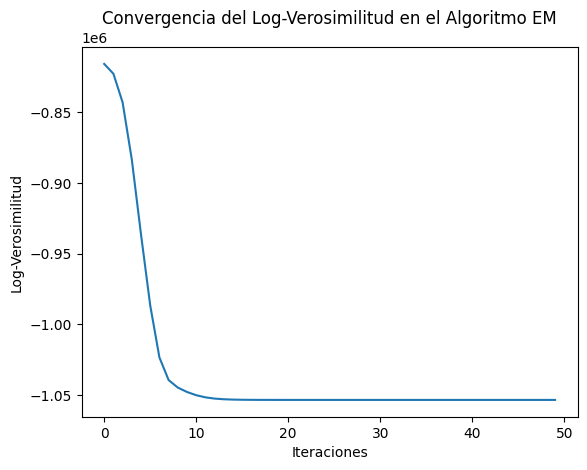

In [ ]:
pi_final, mu_final, Sigma_final, gamma_final, log_likelihoods = expectation_maximization(X_norm, mu, Sigma, pi)

Ahora obtenemos el valor de los cluster resultantes para cada una de las muestras de entrenamiento.

In [ ]:
Z = np.argmax(gamma_final, axis=1)
Z

array([0, 0, 1, ..., 2, 2, 2])

In [ ]:
df['cluster'] = Z

<ipython-input-46-0097338da615>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = Z


Con lo anterior hecho, procedemos a obtener en **rand index** para medir la calidad del clustering realizado en el entramiento.

In [ ]:
# prompt: rand index entre y_train y Z
rand_index = rand_score(df.label, df.cluster)
print(f"Rand Index: {rand_index}")


Rand Index: 0.8591184755469109


El valor obtenido para el rand index (0.8590) para nuestro caso indica que el modelo obtenido por clustering es bueno  ya que explica bastante bien el conjuto de datos para el agrupamiento por "Reputación internacional". A continuación la cantidad de datos por cluster.

In [ ]:
df_players['cluster'] = df['cluster']
df_players['cluster'].value_counts()

,count
cluster,
2,15615
1,1657
3,265
0,85
4,38


Mediante el pair plot, se ilustra el efecto de los cluster sobre los datos.

In [ ]:
sns.pairplot(df, hue='cluster', palette = 'viridis')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 4. Resultados y conclusiones

Si bien 5 cluster pueden explicar bien la característica seleccionada se ve que estos no son adecuados para otra variables. En los graficos anteriores se observa que han superposion de entre las diferentes variables para los 5 closter seleccionados.

In [ ]:
# Agrupar por cluster y calcular estadísticas descriptivas
players_num_cluster_summary = df_players.groupby('cluster').mean(numeric_only=True).round(2)

# Mostrar la tabla
players_num_cluster_summary.T

cluster,0,1,2,3,4
id,203699.53,208548.24,251752.96,181116.40,210627.21
age,28.32,27.86,22.43,32.34,27.05
overall,85.19,76.58,61.59,75.84,83.08
potential,87.07,78.88,69.91,77.41,86.08
special,2021.85,1907.89,1498.40,1326.52,2035.42
international_reputation,3.13,1.63,1.02,1.79,2.68
weak_foot,3.60,3.25,2.86,2.79,3.39
skill_moves,3.34,3.04,2.23,1.34,3.47
kit_number,16.54,18.59,25.96,15.24,15.45


In [ ]:
# Agrupar por cluster y calcular estadísticas descriptivas
players_cat_cluster_summary = df_players.groupby('cluster')[categorical_cols_to_keep].describe().round(2)

# Mostrar la tabla
players_cat_cluster_summary.T

cluster                                0                 1  \
preferred_foot      count             85              1657   
                    unique             2                 2   
                    top            Right             Right   
                    freq              66              1232   
work_rate           count             85              1657   
                    unique             8                10   
                    top     High/ Medium    Medium/ Medium   
                    freq              26               499   
body_type           count             85              1652   
                    unique             8                10   
                    top           Unique  Normal (170-185)   
                    freq              50               536   
real_face           count             85              1652   
                    unique             2                 2   
                    top              Yes               Yes   
                    freq              82               961   
position            count             85              1657   
                    unique            20                29   
                    top              SUB               SUB   
                    freq              18               622   
best_overall_rating count              0                 0   
                    unique             0                 0   
                    top              NaN               NaN   
                    freq             NaN               NaN   

cluster                                                          2  \
preferred_foot      count                                    15615   
                    unique                                       2   
                    top                                      Right   
                    freq                                     12098   
work_rate           count                                    15615   
                    unique                                      10   
                    top                             Medium/ Medium   
                    freq                                      9308   
body_type           count                                    15594   
                    unique                                      10   
                    top                           Normal (170-185)   
                    freq                                      5648   
real_face           count                                    15594   
                    unique                                       2   
                    top                                         No   
                    freq                                     14747   
position            count                                    15615   
                    unique                                      30   
                    top                                        SUB   
                    freq                                      6682   
best_overall_rating count                                       18   
                    unique                                      11   
                    top     <span class="bp3-tag p p-64">64</span>   
                    freq                                         3   

cluster                                                          3  \
preferred_foot      count                                      265   
                    unique                                       2   
                    top                                      Right   
                    freq                                       232   
work_rate           count                                      265   
                    unique                                       8   
                    top                             Medium/ Medium   
                    freq                                       213   
body_type           count                                      253  

* Poner boxplots de las caracteristicas que se originaron de los clusters
* Poner histrogramas y la funcion de probabilidad aproximada despues de la generacion de estos.

<ipython-input-195-cccf8e069570>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'cluster', y ='age', data = df_players, palette='colorblind')


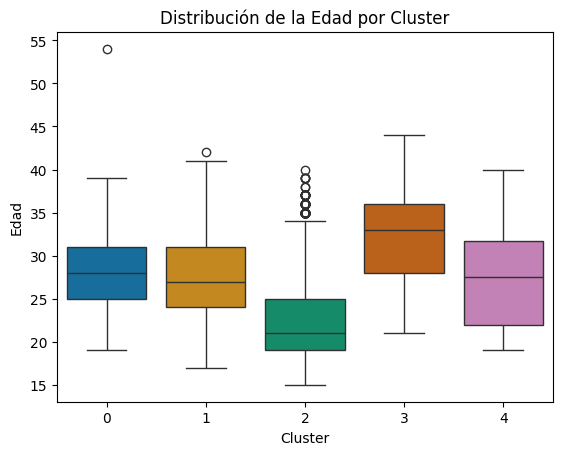

In [ ]:
sns.boxplot(x = 'cluster', y ='age', data = df_players, palette='colorblind')
plt.xlabel('Cluster')
plt.ylabel('Edad')
plt.title('Distribución de la Edad por Cluster')
plt.show()

<ipython-input-201-59a1cf09f0d1>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'cluster', y ='potential', data = df_players, palette='colorblind')


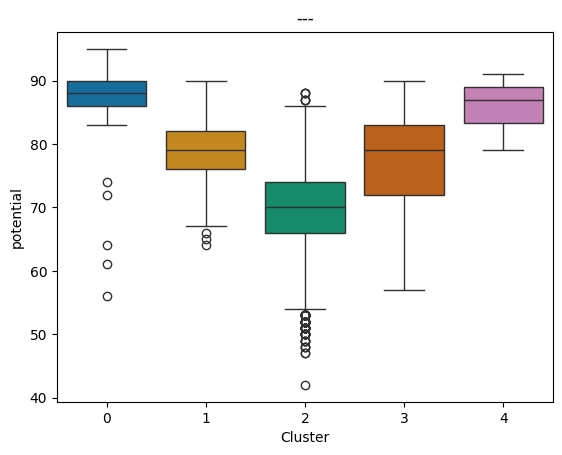

In [ ]:
sns.boxplot(x = 'cluster', y ='potential', data = df_players, palette='colorblind')
plt.xlabel('Cluster')
plt.ylabel('potential')
plt.title('---')
plt.show()

<ipython-input-197-25874733b723>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'cluster', y ='international_reputation', data = df_players, palette='colorblind')


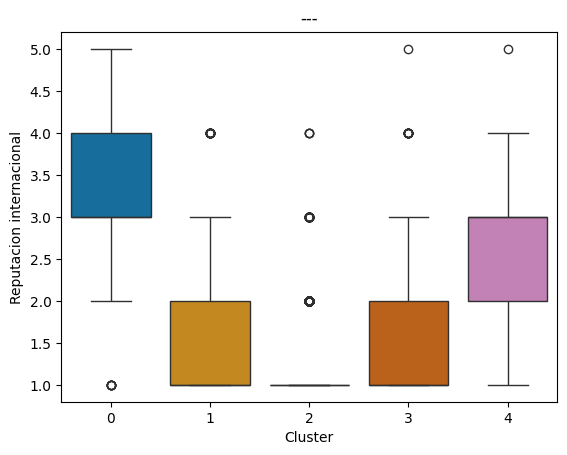

In [ ]:
sns.boxplot(x = 'cluster', y ='international_reputation', data = df_players, palette='colorblind')
plt.xlabel('Cluster')
plt.ylabel('Reputacion internacional')
plt.title('---')
plt.show()

<ipython-input-203-a626453b1625>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'cluster', y ='value', data = df, palette='colorblind')


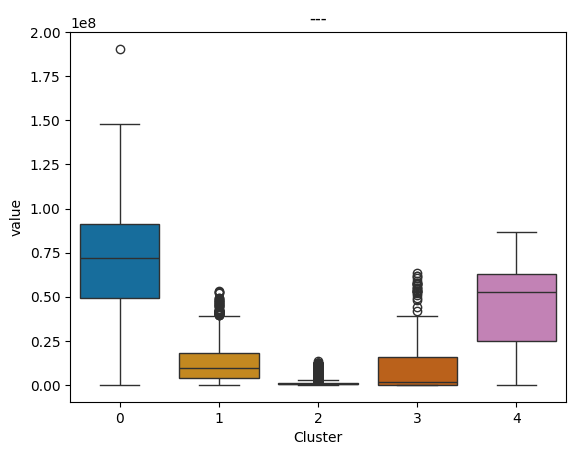

In [ ]:
sns.boxplot(x = 'cluster', y ='value', data = df, palette='colorblind')
plt.xlabel('Cluster')
plt.ylabel('value')
plt.title('---')
plt.show()

<ipython-input-199-ab969aa2cf06>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'cluster', y ='overall', data = df_players, palette='colorblind')


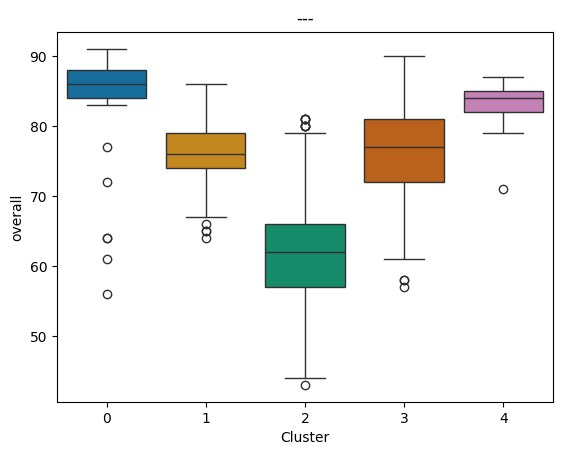

In [ ]:
sns.boxplot(x = 'cluster', y ='overall', data = df_players, palette='colorblind')
plt.xlabel('Cluster')
plt.ylabel('overall')
plt.title('---')
plt.show()

## Dataset aerolineas

La siguiente tabla resume la información del dataset:

| Campo               | Descripción |
|---------------------|-------------|
| ID#                | ID único |
| Balance           | Número de millas elegibles para viajes con premio |
| Qual_miles        | Número de millas que califican para el estatus Topflight |
| cc1_miles        | Número de millas ganadas con la tarjeta de crédito de viajero frecuente en los últimos 12 meses |
| cc2_miles        | Número de millas ganadas con la tarjeta de crédito Rewards en los últimos 12 meses |
| cc3_miles        | Número de millas ganadas con la tarjeta de crédito para pequeñas empresas en los últimos 12 meses |
| Bonus_miles      | Número de millas ganadas por transacciones de bonificación no relacionadas con vuelos en los últimos 12 meses |
| Bonus_trans      | Número de transacciones de bonificación no relacionadas con vuelos en los últimos 12 meses |
| Flight_miles_12mo | Número de millas de vuelo en los últimos 12 meses |
| Flight_trans_12  | Número de transacciones de vuelo en los últimos 12 meses |
| Days_since_enroll | Número de días desde la fecha de inscripción |
| Award?           | Variable indicadora para el último premio (1= no nulo, 0= nulo) |

### 1. Carga de datos

In [ ]:
# Se carga el dataset
xlsx_file = 'EastWestAirlines.xlsx'
df_airlines = pd.read_excel(xlsx_file, sheet_name='data')
df_airlines.head(3)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0


### 2. EDA

In [ ]:
try:
    df_airlines.drop(['cluster'], axis=1, inplace=True)
except KeyError:
    pass

f,c = df_airlines.shape
print(f"El numero de filas en el dataset es de {f}") # Filas
print(f"El numero de columnas en el dataset es de {c}") # Columnas

El numero de filas en el dataset es de 3999
El numero de columnas en el dataset es de 12


In [ ]:
df_airlines.columns = df_airlines.columns.str.lower()
df_airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id#                3999 non-null   int64
 1   balance            3999 non-null   int64
 2   qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   bonus_miles        3999 non-null   int64
 7   bonus_trans        3999 non-null   int64
 8   flight_miles_12mo  3999 non-null   int64
 9   flight_trans_12    3999 non-null   int64
 10  days_since_enroll  3999 non-null   int64
 11  award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [ ]:
# checking the missing values
df_airlines.isnull().sum()

,0
id#,0
balance,0
qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
bonus_miles,0
bonus_trans,0
flight_miles_12mo,0
flight_trans_12,0


Como se puede observar en los resultados anteriores podemos llegar a las siguientes conclusiones:
* Todas las caracteristicas son numericas.
* El dataset esta completo ya que no tiene valores nulos.
* La columna asociada al `id` no se usara pues esta relacionada con cada uno de los registros.
* Es importante resaltar mediante el conteo de valores para cada columna la cantidad de datos diferentes, esto con el fin de determinar cuales de estas variables numericas se asocian a una categoria. Esto se hace a continuación.

In [ ]:
unique_values_count = df_airlines.nunique()
print(unique_values_count)

id#                  3999
balance              3904
qual_miles            164
cc1_miles               5
cc2_miles               3
cc3_miles               5
bonus_miles          2734
bonus_trans            57
flight_miles_12mo     343
flight_trans_12        35
days_since_enroll    2820
award?                  2
dtype: int64


Como se puede ver en el resultado anterior, hay unas variables que tienen pocos valores diferentes: `cc1_miles`, `cc2_miles`, `cc3_miles`  y `award?`.

Para el analisis inicial vamos a eliminar la columna id por ser el identificador de cada uno de los registros

In [ ]:
df2 = df_airlines.drop(columns=['id#'])

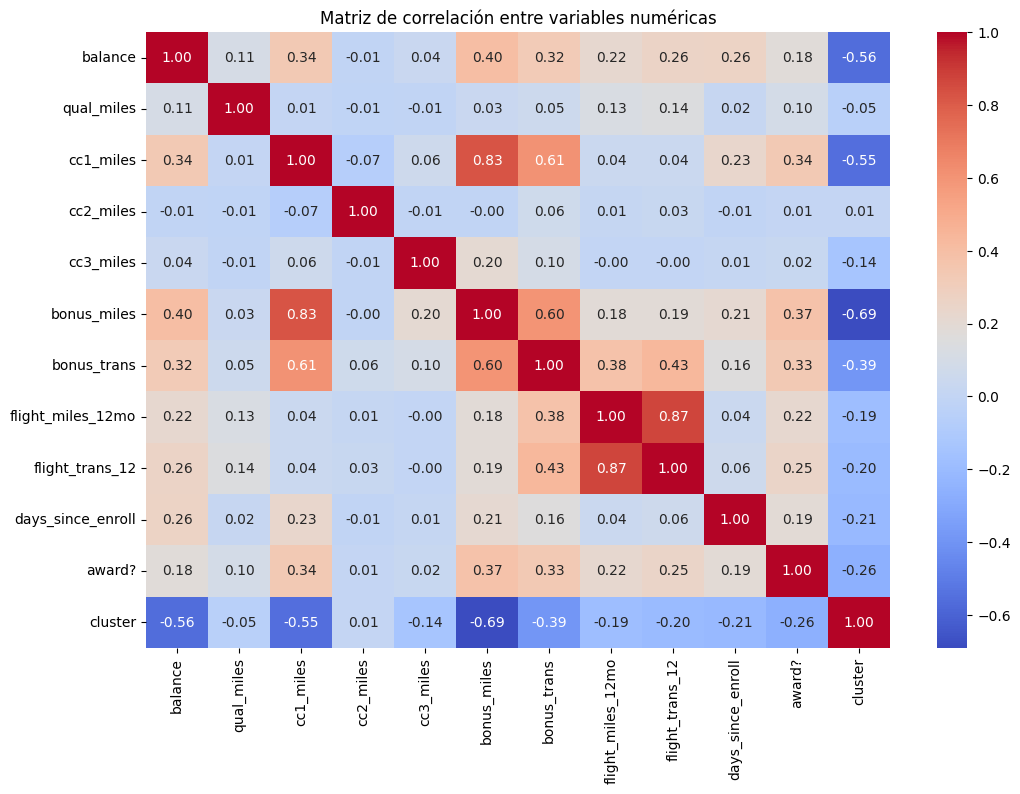

In [ ]:
# Matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Para crear el modelo, vamos a eliminar las columnas `cc1_miles`, `cc2_miles`, `cc3_miles` y `quad_miles` pues parecen ser categoricas; tambien eliminaremos `flight_miles_12mo` y `flight_trans` pues estan muy correlacionadas y tambien parecen tener una tendencia categorica. Estas seran removidas para los procesos que siguen:

In [ ]:
# Remove the specified columns
# df2 = df_airlines.drop(columns=['id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['balance','qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['balance','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df_airlines.drop(columns=['qual_miles','id#', 'bonus_trans', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
# df2 = df2.drop(columns=['qual_miles','cc1_miles', 'cc2_miles', 'cc3_miles','bonus_trans', ,'flight_trans_12'])
# df2 = df2.drop(columns=['qual_miles','cc1_miles', 'cc2_miles', 'cc3_miles','bonus_trans','flight_miles_12mo', 'flight_trans_12'])
# df2 = df2.drop(columns=['cc1_miles', 'cc2_miles', 'cc3_miles','bonus_trans','flight_miles_12mo', 'flight_trans_12'])
df2 = df2.drop(columns=['qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles','bonus_trans','flight_miles_12mo', 'flight_trans_12'])


# Display the updated DataFrame
df2.head(3)

,balance,bonus_miles,days_since_enroll,award?
0,28143,174,7000,0
1,19244,215,6968,0
2,41354,4123,7034,0


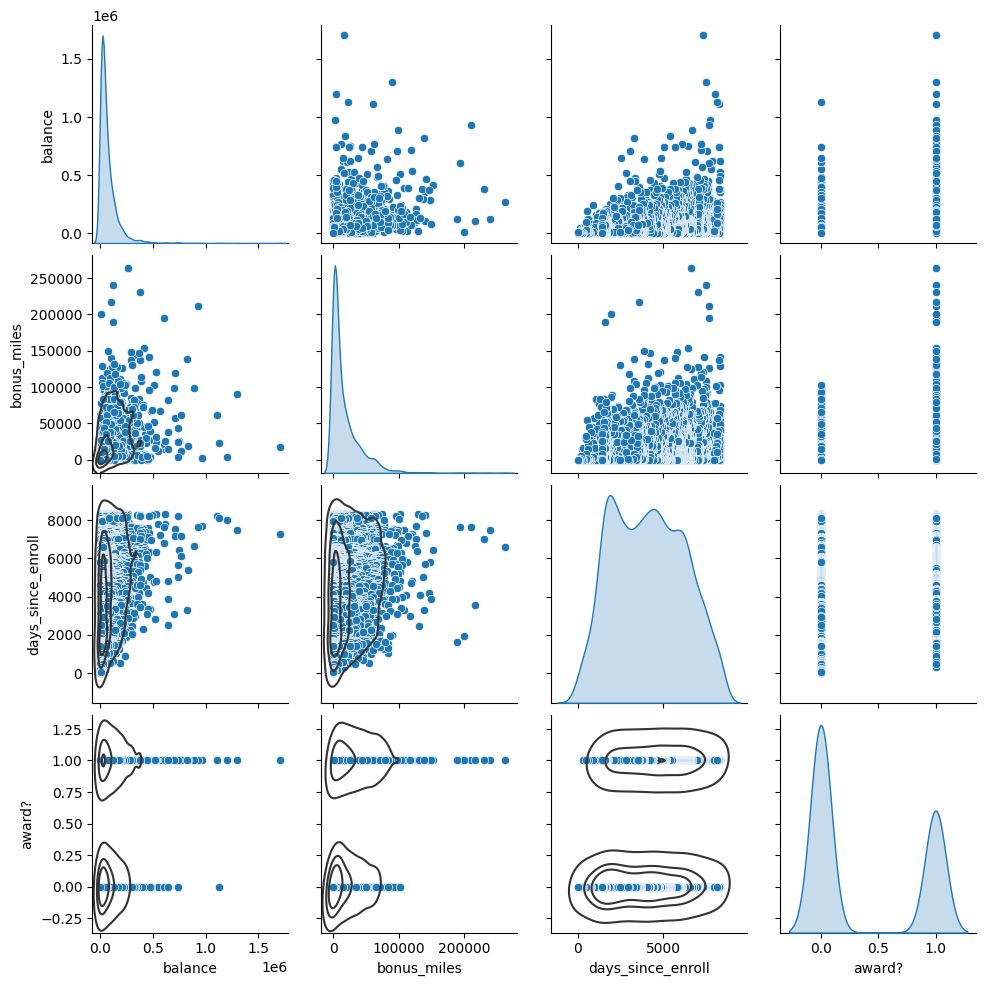

In [ ]:
g = sns.pairplot(df2, diag_kind="kde")
g.map_lower(sns.kdeplot, levels=4, color=".2")

### 3. GMM

In [ ]:
try:
    df2.drop(['cluster'], axis=1, inplace=True)
except KeyError:
    pass
df2.head(3)

,balance,bonus_miles,days_since_enroll,award?
0,28143,174,7000,0
1,19244,215,6968,0
2,41354,4123,7034,0


In [ ]:
X2_df = df2.drop(columns=['award?'])
y = df2['award?']
X2_df.head()

,balance,bonus_miles,days_since_enroll
0,28143,174,7000
1,19244,215,6968
2,41354,4123,7034
3,14776,500,6952
4,97752,43300,6935


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
# np.random.seed(np.random.randint(0, 1000))

In [ ]:
# Initialize parameters
K = 2  # Number of clusters
X2 = X2_df.values
n, d = X2.shape  # Number of samples
print(f"filas: {n}")
print(f"Columnas: {d}")
print(f"Numero de clusters: {K}")

filas: 3999
Columnas: 3
Numero de clusters: 2


In [ ]:
epsilon = 1e-6  # Small value to prevent log(0)

# Create a scaler object
scaler = StandardScaler()

# Normalize data
# X2_norm = (X2 - X2.mean(axis=0)) / X2.std(axis=0)
X2_norm = scaler.fit_transform(X2)


# Mixing coefficients (initial uniform distribution)
pi2 = np.ones(K) / K

# Initialize means using random samples from data
random_indices = np.random.choice(n, K, replace=False)
mu2 = X2_norm[random_indices, :]
# Initialize covariance matrices
Sigma2 = np.array([generate_positive_definite_matrix(d) for _ in range(K)])

Iteración 1, Log-Verosimilitud: -42843.0068
Iteración 2, Log-Verosimilitud: -45307.3116
Iteración 3, Log-Verosimilitud: -47149.9985
Iteración 4, Log-Verosimilitud: -47629.2919
Iteración 5, Log-Verosimilitud: -47493.0381
Iteración 6, Log-Verosimilitud: -47235.5465
Iteración 7, Log-Verosimilitud: -46993.6875
Iteración 8, Log-Verosimilitud: -46791.9828
Iteración 9, Log-Verosimilitud: -46629.7896
Iteración 10, Log-Verosimilitud: -46501.5546
Iteración 11, Log-Verosimilitud: -46401.2279
Iteración 12, Log-Verosimilitud: -46323.3117
Iteración 13, Log-Verosimilitud: -46263.1210
Iteración 14, Log-Verosimilitud: -46216.8017
Iteración 15, Log-Verosimilitud: -46181.2555
Iteración 16, Log-Verosimilitud: -46154.0310
Iteración 17, Log-Verosimilitud: -46133.2096
Iteración 18, Log-Verosimilitud: -46117.3016
Iteración 19, Log-Verosimilitud: -46105.1565
Iteración 20, Log-Verosimilitud: -46095.8890
Iteración 21, Log-Verosimilitud: -46088.8202
Iteración 22, Log-Verosimilitud: -46083.4299
Iteración 23, Log-V

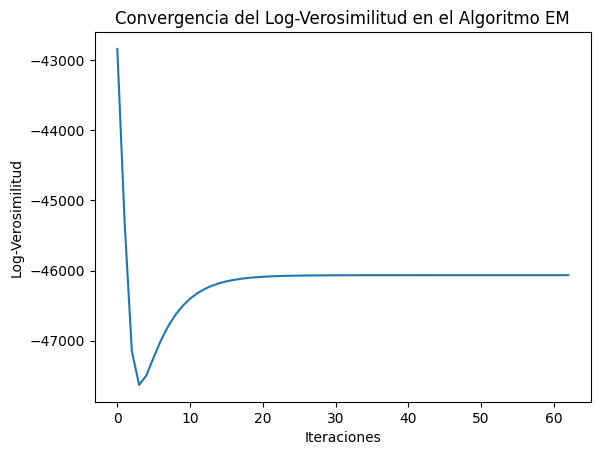

In [ ]:
pi2_final, mu2_final, Sigma2_final, gamma2_final, log_likelihoods = expectation_maximization(X2_norm, mu2, Sigma2, pi2)

In [ ]:
# Assign cluster labels based on maximum responsibility
Z2 = np.argmax(gamma2_final, axis=1)
df2['cluster'] = Z2
df2.head()

,balance,bonus_miles,days_since_enroll,award?,cluster
0,28143,174,7000,0,0
1,19244,215,6968,0,0
2,41354,4123,7034,0,0
3,14776,500,6952,0,0
4,97752,43300,6935,1,0


In [ ]:
df_airlines['cluster'] = df2['cluster']
df_airlines['cluster'].value_counts()

,count
cluster,
0,3490
1,509


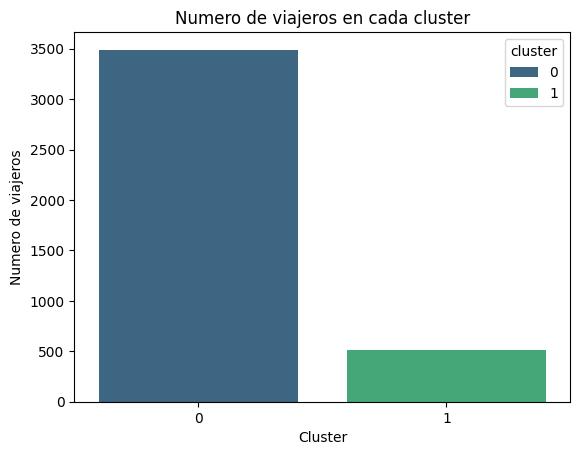

In [ ]:
sns.countplot(x='cluster', data=df_airlines, palette='viridis', hue = 'cluster')
plt.xlabel('Cluster')
plt.ylabel('Numero de viajeros')
plt.title('Numero de viajeros en cada cluster')
plt.show()

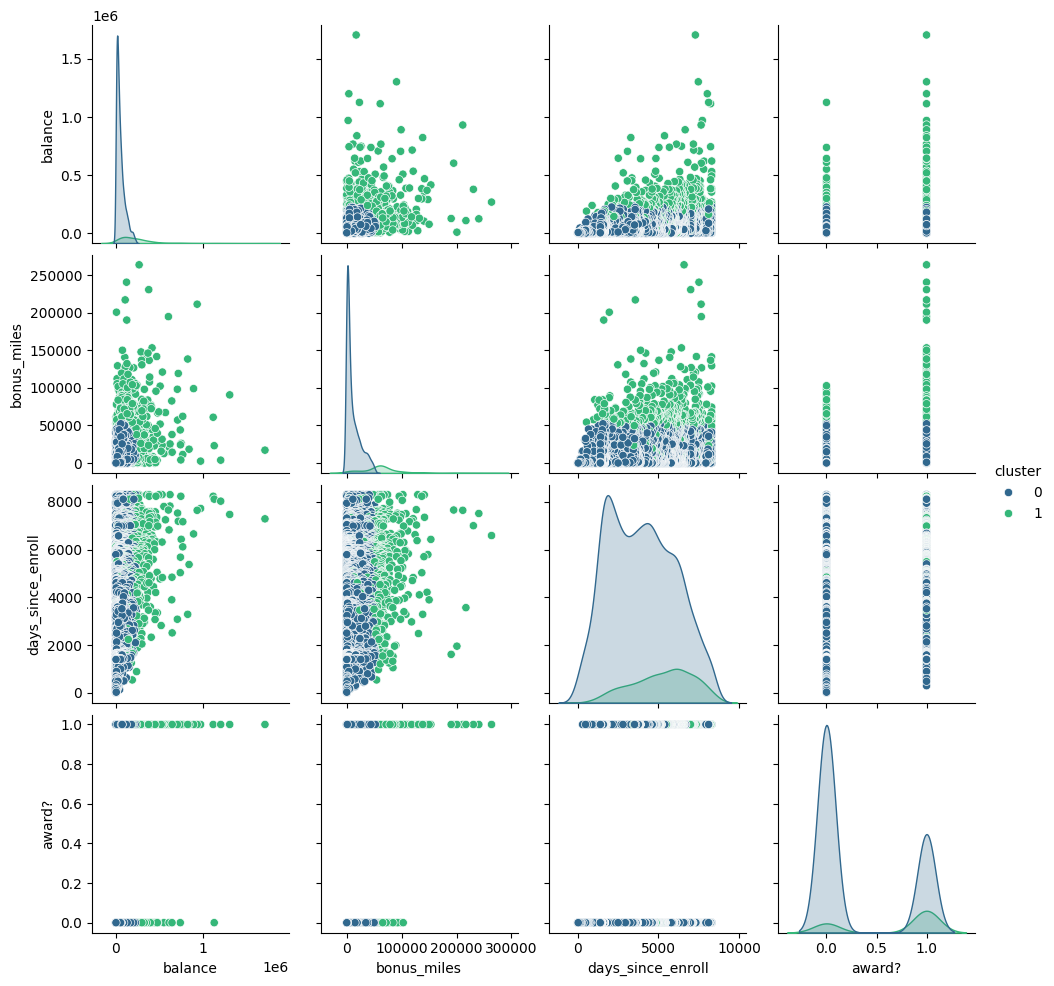

In [ ]:
sns.pairplot(df2, hue='cluster', palette = 'viridis')
plt.show()

In [ ]:
# prompt: rand index entre y_train y Z
rand_index = rand_score(df_airlines['award?'], df_airlines['cluster'])
print(f"Rand Index: {rand_index}")

Rand Index: 0.5657180928548795


In [ ]:
sns.pairplot(df_airlines, hue='cluster', palette = 'viridis')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

-----

In [ ]:
# Agrupar por cluster y calcular estadísticas descriptivas
cluster_summary = df2.groupby('cluster').agg(['min', 'mean', 'max', 'std']).round(2)

# Mostrar la tabla
cluster_summary.T

cluster                         0           1
balance           min        0.00     2843.00
                  mean   52020.93   221569.06
                  max   233449.00  1704838.00
                  std    47504.40   198217.92
bonus_miles       min        0.00        0.00
                  mean   10783.30    60763.31
                  max    52700.00   263685.00
                  std    12682.27    36074.43
days_since_enroll min        2.00      542.00
                  mean    3953.25     5252.05
                  max     8296.00     8296.00
                  std     2044.67     1837.29
award?            min        0.00        0.00
                  mean       0.32        0.70
                  max        1.00        1.00
                  std        0.47        0.46

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13508\1381034775.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='age', data=df, palette='colorblind')


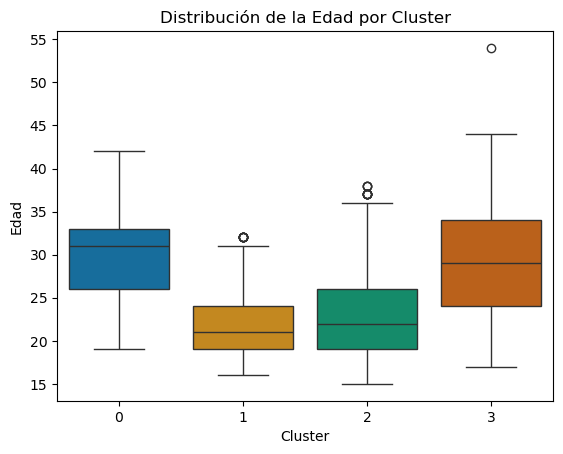

In [ ]:
sns.boxplot(x='cluster', y='age', data=df, palette='colorblind')
plt.xlabel('Cluster')
plt.ylabel('Edad')
plt.title('Distribución de la Edad por Cluster')
plt.show()

#### Conclusiones
* El rand index no es muy bueno para una clasifición por si ganaron o no premio los viajeros, dicha variable está muy desbalanceada hacia los que no ganaron y al ser "binaria" no aportaría mucha información en el conjunto de los datos.
* De las graficas es claro que 2 cluster no logran axplicar adecuadamente todas las variables.